
# 1.   Data Preparation and Processing




In [ ]:
# =========================================
# Importing the Necessary Libraries
# =========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Model Selection and Validation
from sklearn.model_selection import KFold, GridSearchCV

# Imbalanced Data Handling
from imblearn.over_sampling import RandomOverSampler

# Decision Trees
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Ensemble Models
from sklearn.ensemble import (
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier
)

# XGBoost
from xgboost import XGBClassifier

# Datasets
from sklearn.datasets import load_iris

# Evaluation Metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier, plot_tree


In [ ]:
# Load dataset from Excel file
df = pd.read_excel('CPS_Checkpoint_Dataset_Transfers.xlsx')

,ReservationDate,HighSeason,CheckInTimeOfDay,CheckInTime,CheckInDate,TransferRequestTimeRange,ReservationValue,NumOfGuests,LenOfStay,Country,Apartments.Region,Apartments.Neighbourhood,AirportDistanceKm,Transfer - Y/N
0,2022-01-13,no,afternoon,13:00:00,2023-01-03,355,343.440,3.0,4,GB,Lisboa,Av. da Liberdade,7.6,no
1,2022-05-05,no,evening,18:00:00,2022-12-18,227,726.336,4.0,3,Unknown,Lisboa,Av. da Liberdade,7.6,yes
2,2022-09-22,no,afternoon,12:00:00,2023-04-26,216,1823.040,4.0,7,ES,Lisboa,Av. da Liberdade,7.6,no
3,2022-10-09,no,morning,10:00:00,2023-05-14,217,1044.120,4.0,4,NL,Lisboa,Av. da Liberdade,7.6,yes
4,2022-10-10,no,morning,08:00:00,2023-01-24,106,1526.400,4.0,6,BR,Lisboa,Av. da Liberdade,7.6,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22657,2023-12-30,no,unknown,NaN,2023-12-30,0,570.960,3.0,2,ES,Lisboa,Intendente,5.5,no
22658,2023-12-30,no,unknown,NaN,2023-12-30,0,1255.920,2.0,5,FR,Lisboa,Alfama,6.8,no
22659,2023-12-30,no,afternoon,17:00:00,2023-12-30,0,475.200,3.0,2,FR,Lisboa,Madragoa,10.0,no
22660,2023-12-30,no,afternoon,15:00:00,2023-12-30,0,980.448,3.0,2,PT,Lisboa,Av. Novas,5.6,no


The data preprocessing stage was conducted primarily in Excel, where missing values were handled, invalid entries were corrected or removed, and the dataset was cleaned to ensure greater consistency and reliability before being imported into the analytical environment.

## 1.1. Multivariate Data Analysis

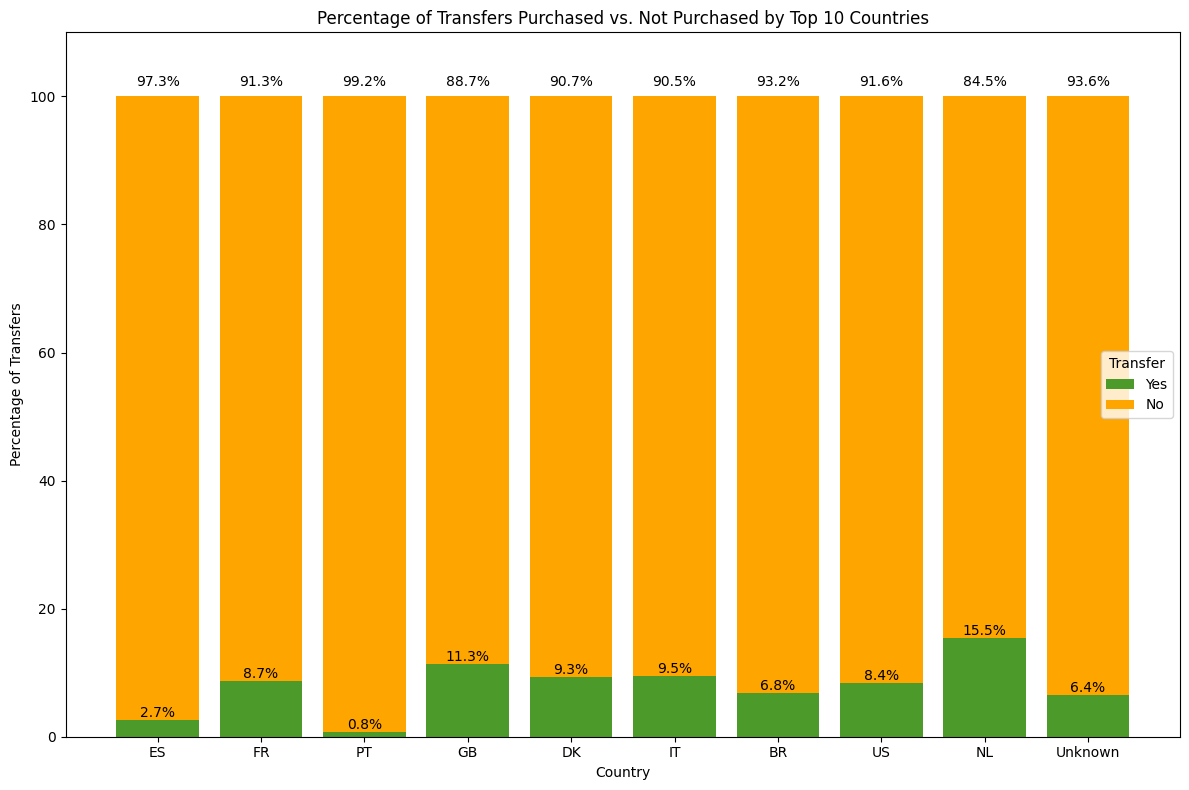

In [ ]:
# =========================================
# Percentage of Purchased vs. Not Purchased Transfers by Top 10 Countries
# =========================================

# Calculate the number of transfers purchased and not purchased by country
transfer_counts = df.groupby(['Country', 'Transfer - Y/N']).size().unstack().fillna(0)

# Calculate total bookings and percentages for each category
transfer_counts['total'] = transfer_counts.sum(axis=1)
transfer_counts['yes_pct'] = (transfer_counts['yes'] / transfer_counts['total']) * 100
transfer_counts['no_pct'] = (transfer_counts['no'] / transfer_counts['total']) * 100

# Select the top 10 countries with the highest number of bookings
top_countries = transfer_counts.sort_values('total', ascending=False).head(10)

# Create the stacked vertical bar chart
fig, ax = plt.subplots(figsize=(12, 8))
ax.bar(top_countries.index, top_countries['yes_pct'], label='Yes', color='#4C9A2A')
ax.bar(top_countries.index, top_countries['no_pct'], bottom=top_countries['yes_pct'], label='No', color='#FFA500')

# Add labels and title
plt.xlabel('Country')
plt.ylabel('Percentage of Transfers')
plt.title('Percentage of Transfers Purchased vs. Not Purchased by Top 10 Countries')
plt.legend(title='Transfer')

# Adjust y-axis limit
y_max = max(top_countries['yes_pct'] + top_countries['no_pct']) * 1.1
ax.set_ylim(0, y_max)

# Add percentage labels on each bar
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        label_position = bar.get_y() + height
        if bar.get_y() > 0:
            label_position += y_max * 0.01
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_position,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            color='black'
        )

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

Analyzing the pattern of transfer purchases across the top 10 countries (i.e., the countries with the highest number of apartment bookings), we observe a stronger tendency to purchase transfers in the following countries: NL, GB, IT, DK, and FR. These will constitute the top 5 countries to be included in our predictive dataset, while the remaining countries will be grouped under the category "Others".

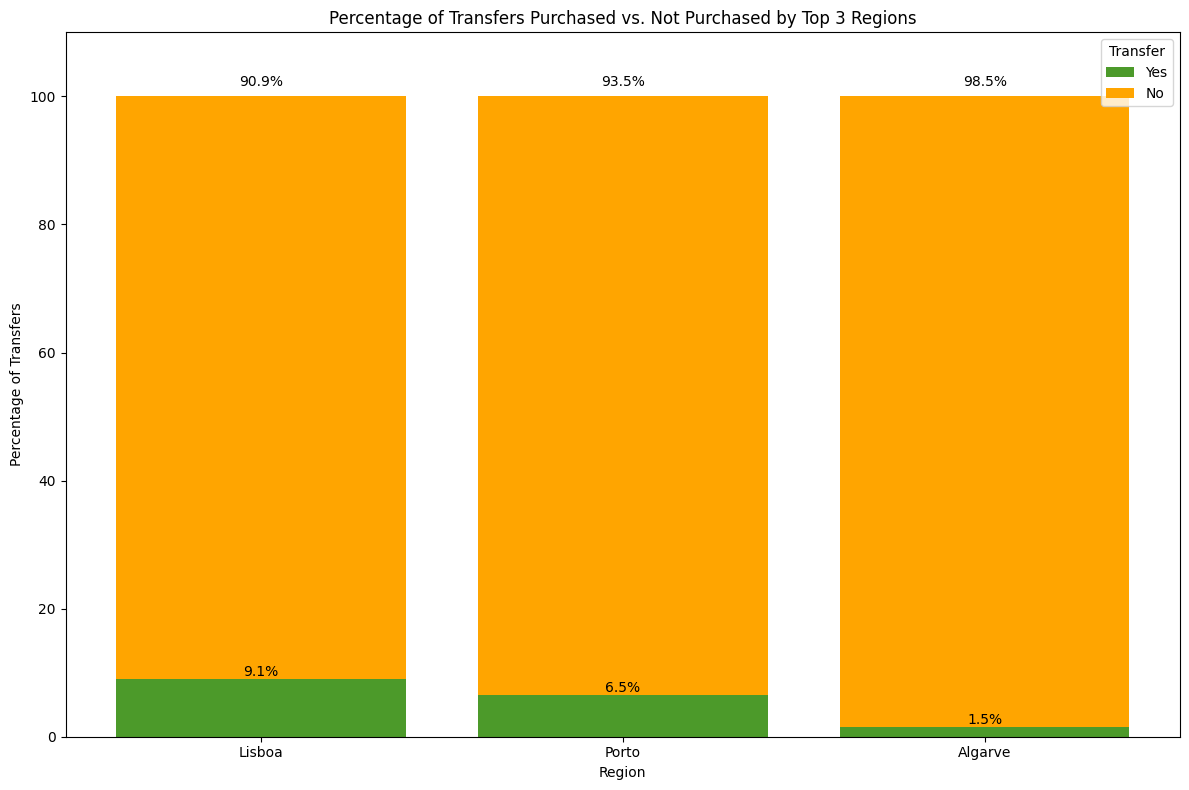

In [ ]:
# =========================================
# Percentage of Purchased vs. Not Purchased Transfers by Top 3 Regions
# =========================================

# Calculate the number of transfers purchased and not purchased by region
region_transfer_counts = df.groupby(['Apartments.Region', 'Transfer - Y/N']).size().unstack().fillna(0)

# Calculate total bookings and percentages for each category
region_transfer_counts['total'] = region_transfer_counts.sum(axis=1)
region_transfer_counts['yes_pct'] = (region_transfer_counts['yes'] / region_transfer_counts['total']) * 100
region_transfer_counts['no_pct'] = (region_transfer_counts['no'] / region_transfer_counts['total']) * 100

# Select the top 3 regions with the highest number of bookings
top_regions = region_transfer_counts.sort_values('total', ascending=False).head(3)

# Create the stacked vertical bar chart
fig, ax = plt.subplots(figsize=(12, 8))
ax.bar(top_regions.index, top_regions['yes_pct'], label='Yes', color='#4C9A2A')
ax.bar(top_regions.index, top_regions['no_pct'], bottom=top_regions['yes_pct'], label='No', color='#FFA500')

# Add labels and title
plt.xlabel('Region')
plt.ylabel('Percentage of Transfers')
plt.title('Percentage of Transfers Purchased vs. Not Purchased by Top 3 Regions')
plt.legend(title='Transfer')

# Adjust y-axis limit
y_max = max(top_regions['yes_pct'] + top_regions['no_pct']) * 1.1
ax.set_ylim(0, y_max)

# Add percentage labels on each bar
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        label_position = bar.get_y() + height
        if bar.get_y() > 0:
            label_position += y_max * 0.01
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_position,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            color='black'
        )

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In the chart above, it can be observed that the two regions with the highest percentage of transfer purchases, relative to the number of bookings made, were Lisbon and Porto. Therefore, for our predictive dataset, the remaining regions (Algarve and Ericeira) will be grouped under the category “Others.”

/tmp/ipykernel_3060/2125190977.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(filtered_proportions.index, rotation=45, ha='right', fontsize=10)


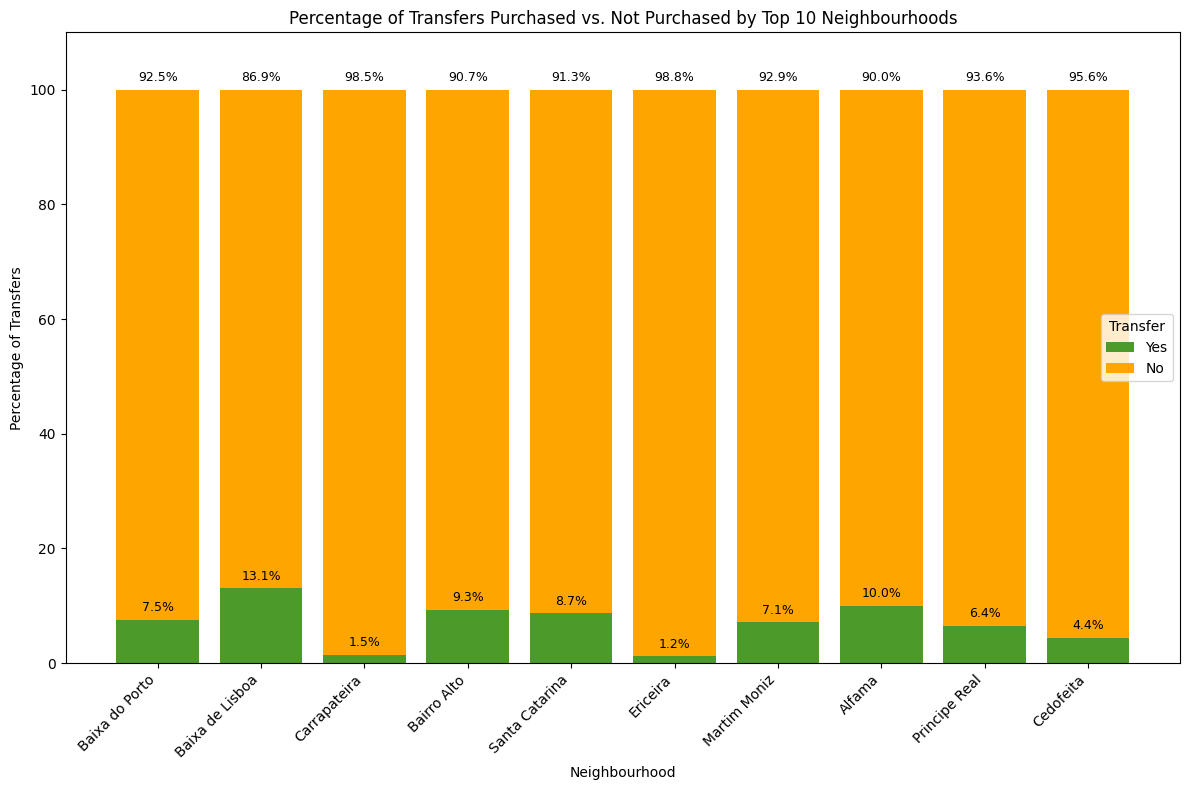

In [ ]:
# =========================================
# Percentage of Purchased vs. Not Purchased Transfers by Top 10 Neighbourhoods
# =========================================

# Create a cross-tabulation of neighbourhoods and transfer purchases
neighbourhood_transfer_counts = pd.crosstab(
    df['Apartments.Neighbourhood'],
    df['Transfer - Y/N']
)

# Calculate transfer purchase proportions by neighbourhood
transfer_proportions = neighbourhood_transfer_counts.div(
    neighbourhood_transfer_counts.sum(axis=1),
    axis=0
)

# Convert proportions into percentages
transfer_proportions['yes_pct'] = transfer_proportions['yes'] * 100
transfer_proportions['no_pct'] = transfer_proportions['no'] * 100

# Select the top 10 neighbourhoods with the highest number of bookings
top_neighbourhoods = neighbourhood_transfer_counts.sum(axis=1).nlargest(10)
filtered_proportions = transfer_proportions.loc[top_neighbourhoods.index]

# Create the stacked vertical bar chart
fig, ax = plt.subplots(figsize=(12, 8))
bars_yes = ax.bar(
    filtered_proportions.index,
    filtered_proportions['yes_pct'],
    label='Yes',
    color='#4C9A2A'
)
bars_no = ax.bar(
    filtered_proportions.index,
    filtered_proportions['no_pct'],
    bottom=filtered_proportions['yes_pct'],
    label='No',
    color='#FFA500'
)

# Add labels and title
ax.set_xlabel('Neighbourhood')
ax.set_ylabel('Percentage of Transfers')
ax.set_title('Percentage of Transfers Purchased vs. Not Purchased by Top 10 Neighbourhoods')
ax.set_xticklabels(filtered_proportions.index, rotation=45, ha='right', fontsize=10)

# Adjust y-axis limit
y_max = max(filtered_proportions['yes_pct'] + filtered_proportions['no_pct']) * 1.1
ax.set_ylim(0, y_max)

# Add percentage labels on each bar
for bars in [bars_yes, bars_no]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            label_position = bar.get_y() + height
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                label_position + 1,
                f'{height:.1f}%',
                ha='center',
                va='bottom',
                color='black',
                fontsize=9
            )

# Add legend and display the plot
ax.legend(title='Transfer')
plt.tight_layout()
plt.show()

Analyzing the pattern of transfer purchases across the top 10 neighbourhoods, that is, the neighbourhoods with the highest number of apartment bookings, we observe a stronger tendency to purchase transfers when the apartment is located in Baixa de Lisboa, Alfama, Bairro Alto, Santa Catarina, and Baixa do Porto. These will constitute the top 5 neighbourhoods to be included in our predictive dataset, while the remaining neighbourhoods will be grouped under the category “Others.”

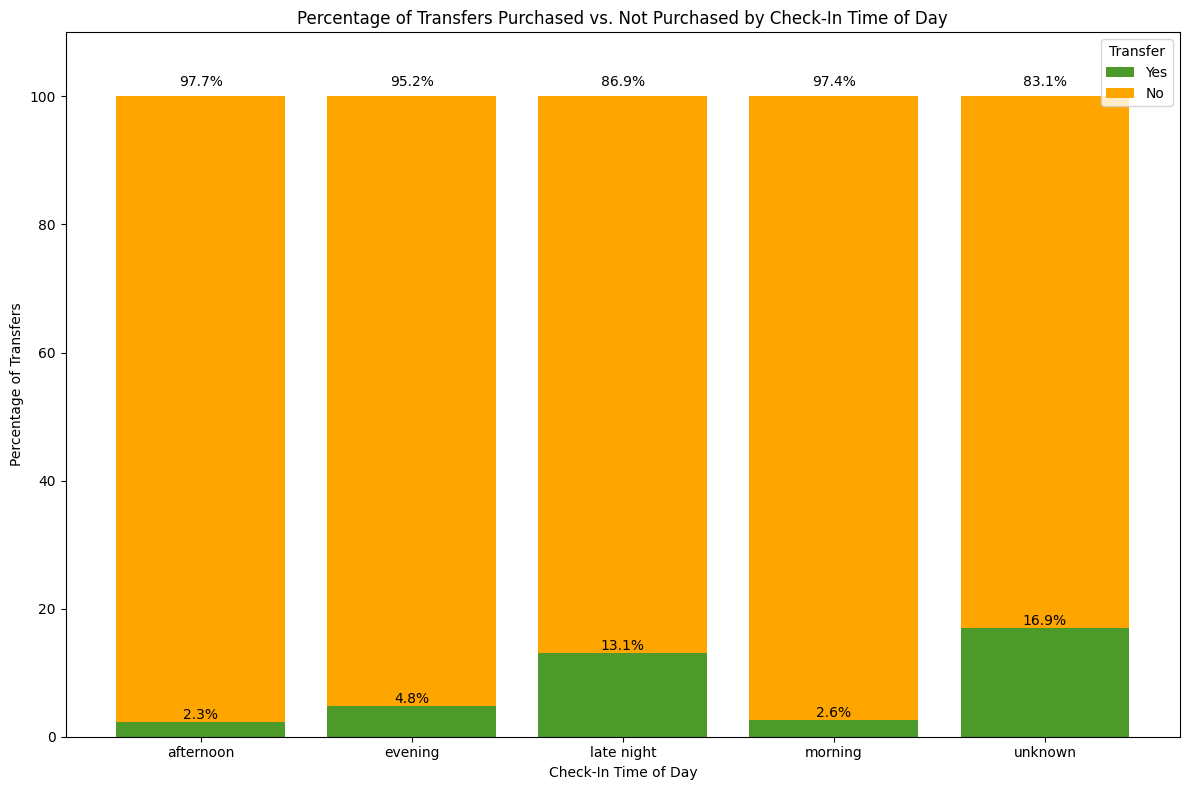

In [ ]:
# =========================================
# Percentage of Purchased vs. Not Purchased Transfers by Check-In Time of Day
# =========================================

# Calculate the number of transfers purchased and not purchased by check-in time of day
transfer_counts_checkin = df.groupby(["CheckInTimeOfDay", "Transfer - Y/N"]).size().unstack().fillna(0)

# Calculate total bookings and percentages for each category
transfer_counts_checkin["total"] = transfer_counts_checkin.sum(axis=1)
transfer_counts_checkin["yes_pct"] = (transfer_counts_checkin["yes"] / transfer_counts_checkin["total"]) * 100
transfer_counts_checkin["no_pct"] = (transfer_counts_checkin["no"] / transfer_counts_checkin["total"]) * 100

# Create the stacked vertical bar chart
fig, ax = plt.subplots(figsize=(12, 8))
ax.bar(transfer_counts_checkin.index, transfer_counts_checkin["yes_pct"], label="Yes", color="#4C9A2A")
ax.bar(transfer_counts_checkin.index, transfer_counts_checkin["no_pct"], bottom=transfer_counts_checkin["yes_pct"], label="No", color="#FFA500")

# Add labels and title
plt.xlabel("Check-In Time of Day")
plt.ylabel("Percentage of Transfers")
plt.title("Percentage of Transfers Purchased vs. Not Purchased by Check-In Time of Day")
plt.legend(title="Transfer")

# Adjust y-axis limit
y_max = max(transfer_counts_checkin["yes_pct"] + transfer_counts_checkin["no_pct"]) * 1.1
ax.set_ylim(0, y_max)

# Add percentage labels on each bar
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        label_position = bar.get_y() + height
        if bar.get_y() > 0:
            label_position += y_max * 0.01
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_position,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            color="black"
        )

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

Analyzing transfer purchases according to the created variable “CheckInTimeOfDay,” we can observe a stronger tendency to purchase transfers during the late night period. However, it is important to note that this value is lower than the results for the “unknown” category, that is, cases in which the “CheckIn” field was not filled in, representing 31.03% of the total records.

It can also be observed that there is a strong tendency not to purchase a transfer service during the morning and afternoon periods. This leads us to group these two values into a single category: “Others.”

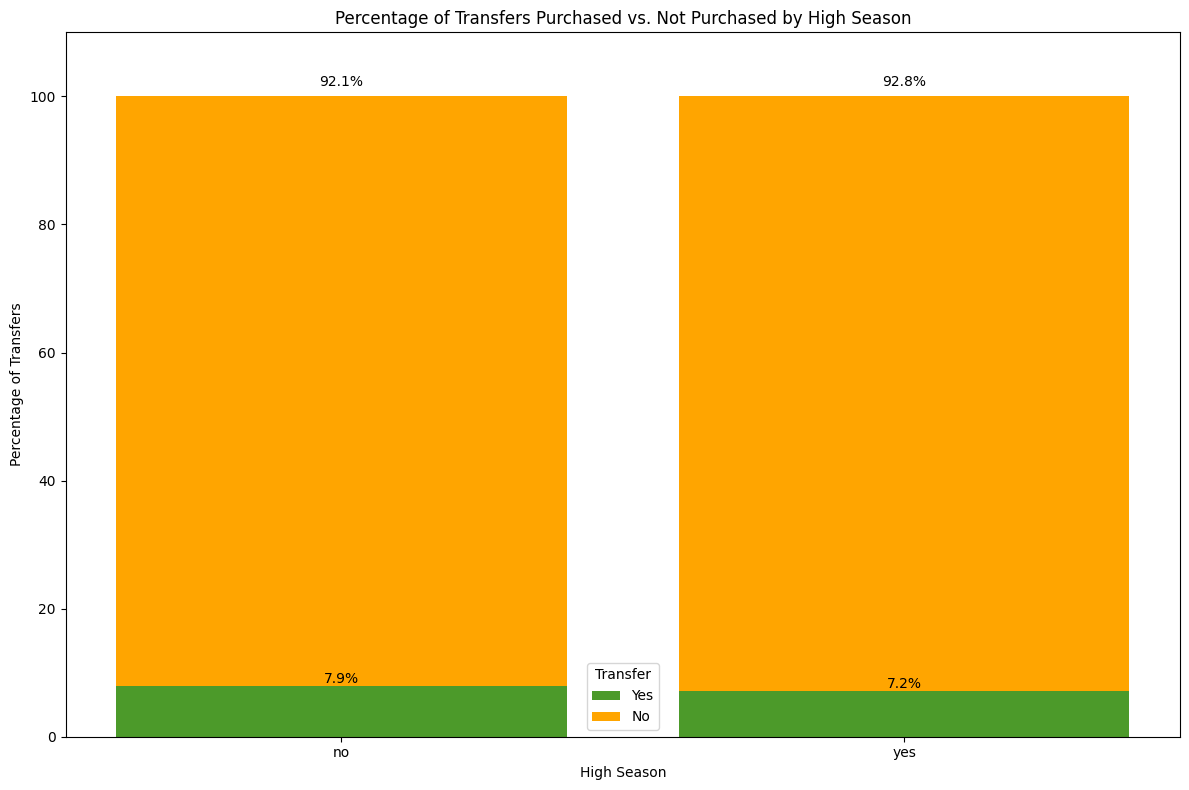

In [ ]:
# =========================================
# Percentage of Purchased vs. Not Purchased Transfers by High Season
# =========================================

# Calculate the number of transfers purchased and not purchased by high season
transfer_counts_highseason = df.groupby(["HighSeason", "Transfer - Y/N"]).size().unstack().fillna(0)

# Calculate total bookings and percentages for each category
transfer_counts_highseason["total"] = transfer_counts_highseason.sum(axis=1)
transfer_counts_highseason["yes_pct"] = (transfer_counts_highseason["yes"] / transfer_counts_highseason["total"]) * 100
transfer_counts_highseason["no_pct"] = (transfer_counts_highseason["no"] / transfer_counts_highseason["total"]) * 100

# Create the stacked vertical bar chart
fig, ax = plt.subplots(figsize=(12, 8))
ax.bar(transfer_counts_highseason.index, transfer_counts_highseason["yes_pct"], label="Yes", color="#4C9A2A")
ax.bar(transfer_counts_highseason.index, transfer_counts_highseason["no_pct"], bottom=transfer_counts_highseason["yes_pct"], label="No", color="#FFA500")

# Add labels and title
plt.xlabel("High Season")
plt.ylabel("Percentage of Transfers")
plt.title("Percentage of Transfers Purchased vs. Not Purchased by High Season")

# Adjust y-axis limit
y_max = max(transfer_counts_highseason["yes_pct"] + transfer_counts_highseason["no_pct"]) * 1.1
ax.set_ylim(0, y_max)

# Add percentage labels on each bar
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        label_position = bar.get_y() + height
        if bar.get_y() > 0:
            label_position += y_max * 0.01
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_position,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            color="black"
        )

# Add legend and display the plot
plt.legend(title="Transfer")
plt.tight_layout()
plt.show()

Regarding the High Season variable, we can conclude that there is no significant difference in transfer purchases. This may suggest that, at first glance, this variable is not a determining factor in explaining the purchase of transfers.

/tmp/ipykernel_3060/2644558412.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transfer_counts_distance = df.groupby(["DistanceGroup", "Transfer - Y/N"]).size().unstack().fillna(0)


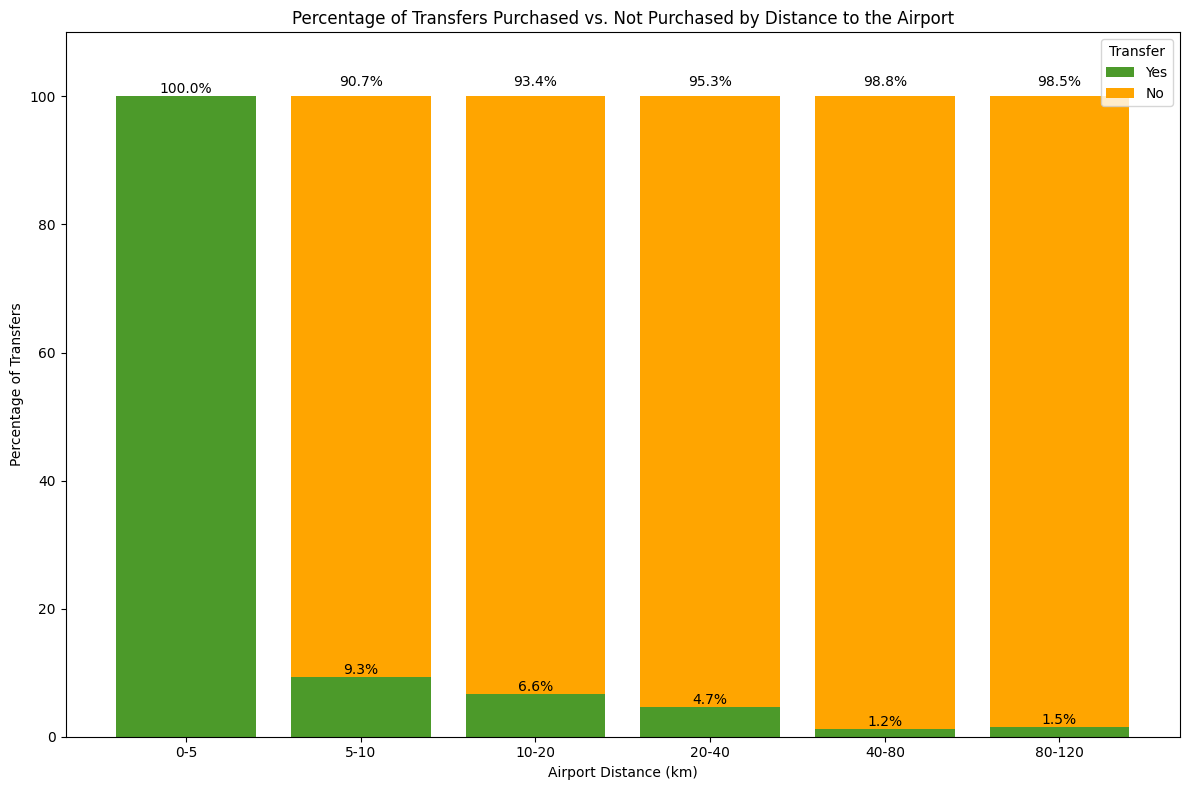

In [ ]:
# =========================================
# Percentage of Purchased vs. Not Purchased Transfers by Distance to the Airport
# =========================================

# Create distance intervals (bins) for analysis
df['DistanceGroup'] = pd.cut(
    df['AirportDistanceKm'],
    bins=[0, 5, 10, 20, 40, 80, 120],
    labels=['0-5', '5-10', '10-20', '20-40', '40-80', '80-120']
)

# Calculate the number of transfers purchased and not purchased by distance group
transfer_counts_distance = df.groupby(["DistanceGroup", "Transfer - Y/N"]).size().unstack().fillna(0)

# Calculate total bookings and percentages for each category
transfer_counts_distance["total"] = transfer_counts_distance.sum(axis=1)
transfer_counts_distance["yes_pct"] = (transfer_counts_distance["yes"] / transfer_counts_distance["total"]) * 100
transfer_counts_distance["no_pct"] = (transfer_counts_distance["no"] / transfer_counts_distance["total"]) * 100

# Create the stacked vertical bar chart
fig, ax = plt.subplots(figsize=(12, 8))
ax.bar(transfer_counts_distance.index, transfer_counts_distance["yes_pct"], label="Yes", color="#4C9A2A")
ax.bar(transfer_counts_distance.index, transfer_counts_distance["no_pct"], bottom=transfer_counts_distance["yes_pct"], label="No", color="#FFA500")

# Add labels and title
plt.xlabel("Airport Distance (km)")
plt.ylabel("Percentage of Transfers")
plt.title("Percentage of Transfers Purchased vs. Not Purchased by Distance to the Airport")

# Adjust y-axis limit
y_max = max(transfer_counts_distance["yes_pct"] + transfer_counts_distance["no_pct"]) * 1.1
ax.set_ylim(0, y_max)

# Add percentage labels on each bar
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        label_position = bar.get_y() + height
        if bar.get_y() > 0:
            label_position += y_max * 0.01
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_position,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            color="black"
        )

# Add legend and display the plot
plt.legend(title="Transfer")
plt.tight_layout()
plt.show()

Note: There is only one neighbourhood (Olivais) that falls within the 0–5 km interval and, for that neighbourhood, there was only one apartment booking. This means that the 0–5 km data should not be interpreted, as it has no statistical relevance that would allow any meaningful conclusions to be drawn from this interval.

Overall, there is a gradual downward trend in the purchase of transfer services as the distance between the airport and the apartment increases, possibly due to the higher cost of this service associated with longer distances.

In [ ]:
df = df.drop(columns=['DistanceGroup'])

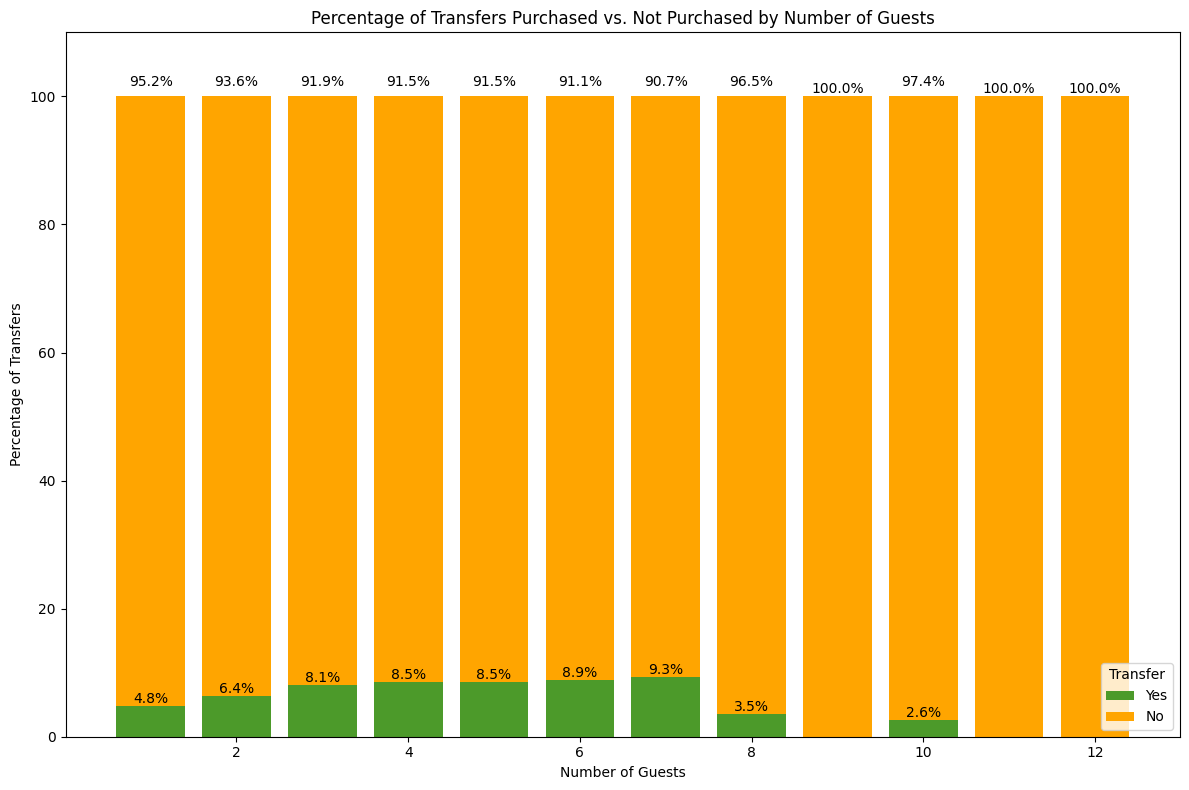

In [ ]:
# =========================================
# Percentage of Purchased vs. Not Purchased Transfers by Number of Guests
# =========================================

# Calculate the number of transfers purchased and not purchased by number of guests
transfer_counts_guests = df.groupby(["NumOfGuests", "Transfer - Y/N"]).size().unstack().fillna(0)

# Calculate total bookings and percentages for each category
transfer_counts_guests["total"] = transfer_counts_guests.sum(axis=1)
transfer_counts_guests["yes_pct"] = (transfer_counts_guests["yes"] / transfer_counts_guests["total"]) * 100
transfer_counts_guests["no_pct"] = (transfer_counts_guests["no"] / transfer_counts_guests["total"]) * 100

# Create the stacked vertical bar chart
fig, ax = plt.subplots(figsize=(12, 8))
ax.bar(transfer_counts_guests.index, transfer_counts_guests["yes_pct"], label="Yes", color="#4C9A2A")
ax.bar(transfer_counts_guests.index, transfer_counts_guests["no_pct"], bottom=transfer_counts_guests["yes_pct"], label="No", color="#FFA500")

# Add labels and title
plt.xlabel("Number of Guests")
plt.ylabel("Percentage of Transfers")
plt.title("Percentage of Transfers Purchased vs. Not Purchased by Number of Guests")
plt.legend(title="Transfer")

# Adjust y-axis limit
y_max = max(transfer_counts_guests["yes_pct"] + transfer_counts_guests["no_pct"]) * 1.1
ax.set_ylim(0, y_max)

# Add percentage labels on each bar
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        label_position = bar.get_y() + height
        if bar.get_y() > 0:
            label_position += y_max * 0.01
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_position,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            color="black"
        )

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

When analyzing this chart, we observe that smaller groups tend to request more transfers compared to larger groups. However, groups with more than 10 guests also show some transfer requests relative to the other groups, although the percentage remains low.

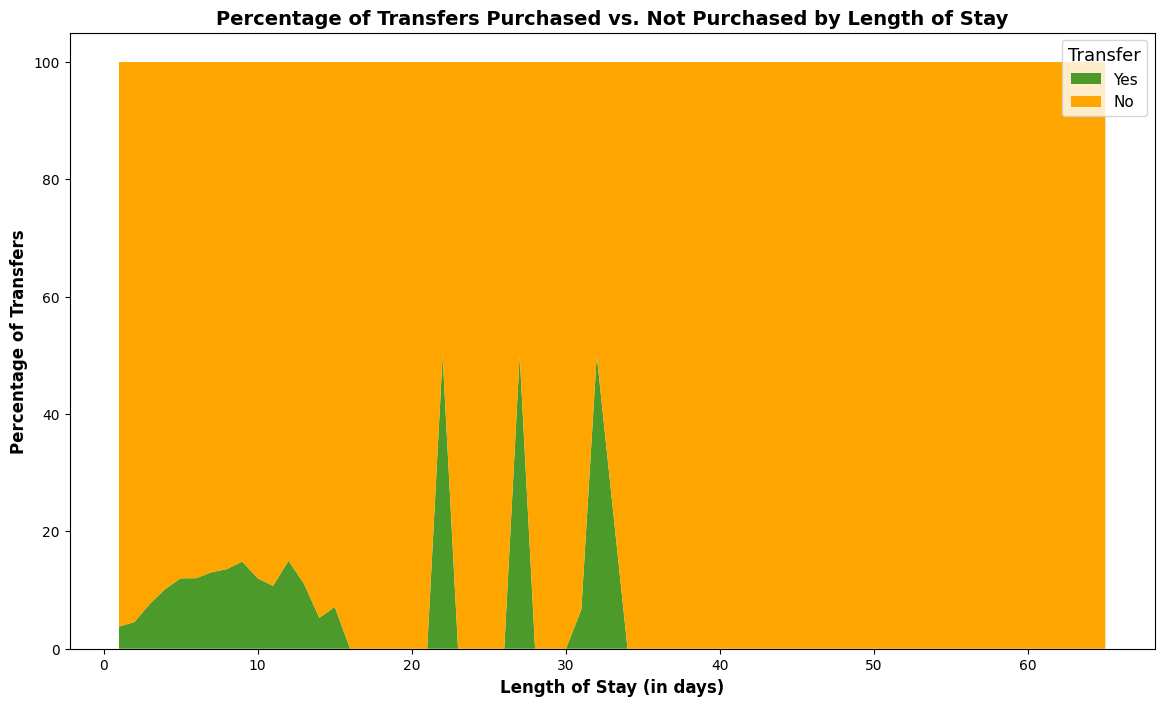

In [ ]:
# =========================================
# Percentage of Purchased vs. Not Purchased Transfers by Length of Stay
# =========================================

lenofstay_counts = df.groupby(["LenOfStay", "Transfer - Y/N"]).size().unstack().fillna(0)
lenofstay_counts["total"] = lenofstay_counts.sum(axis=1)
lenofstay_counts["yes_pct"] = (lenofstay_counts["yes"] / lenofstay_counts["total"]) * 100
lenofstay_counts["no_pct"] = (lenofstay_counts["no"] / lenofstay_counts["total"]) * 100

fig, ax = plt.subplots(figsize=(14, 8))
ax.stackplot(lenofstay_counts.index, lenofstay_counts["yes_pct"], lenofstay_counts["no_pct"], labels=['Yes', 'No'], colors=['#4C9A2A', '#FFA500'])
plt.xlabel("Length of Stay (in days)", fontsize=12, fontweight='bold')
plt.ylabel("Percentage of Transfers", fontsize=12, fontweight='bold')
plt.title("Percentage of Transfers Purchased vs. Not Purchased by Length of Stay", fontsize=14, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Transfer", loc='upper right', title_fontsize='13', fontsize='11')
plt.show()

Shorter stays tend to show a higher percentage of transfer requests. This likely occurs because many guests seek convenience upon arrival, especially those who are unfamiliar with the area or prefer to avoid the hassle of arranging their own transportation after a long journey.

## 1.2. Transformation of Non-Numeric Variables

Transformations to be applied:

* HighSeason and Transfer - Y/N: we will convert 'yes' to 1 and 'no' to 0.
* Country and Apartments.Neighbourhood: we will select the top 5 categories with the highest proportion of purchased transfers (highest percentage of transfers = 'yes'), and group the remaining categories under “Others.” Then, we will transform these variables into binary variables (0/1) using the get_dummies function.
* Apartments.Region: we will select the 2 regions with the highest number of purchased transfer services, and group the remaining regions under “Others.” Then, we will apply the get_dummies function to convert this variable into a binary format.
* CheckInTimeOfDay: we will select the 3 periods of the day with the highest number of purchased transfers, and group the remaining categories under “Others.” Then, we will apply the get_dummies function to convert this variable into a binary format.
* ReservationDate, CheckInDate, and CheckInTime: we decided not to include these variables in the model, that is, they will be removed, since HighSeason already reflects ReservationDate (it corresponds to the four high-season months — June to September — derived from the reservation date), and CheckInTimeOfDay already reflects CheckInTime (the categories late night, morning, afternoon, and night were created based on the check-in time).
* ReservationValue and NumOfGuests: null values will be replaced with the mean.

In [ ]:
# =========================================
# Convert Binary Categorical Variables into Numerical Format
# =========================================

In [ ]:
# Replace 'yes' and 'no' with 1 and 0 in the 'HighSeason' and 'Transfer - Y/N' columns
df['HighSeason'] = df['HighSeason'].map({'yes': 1, 'no': 0})
df['Transfer - Y/N'] = df['Transfer - Y/N'].map({'yes': 1, 'no': 0})

In [ ]:
# =========================================
# Group Country Categories and Keep Only the Top 5
# =========================================
# Select the top 5 countries with the highest percentage of purchased transfers
top_countries = ['NL', 'GB', 'IT', 'DK', 'FR']

# Replace all remaining countries with 'Others'
df['Country'] = df['Country'].apply(lambda x: x if x in top_countries else 'Others')

# Display the distinct values in the 'Country' column
unique_countries = df['Country'].unique()
print("Unique values in 'Country':", unique_countries)

Unique values in 'Country': ['GB' 'Others' 'NL' 'DK' 'FR' 'IT']


In [ ]:
# =========================================
# Group Neighbourhood Categories and Keep Only the Top 5
# =========================================

# Select the top 5 neighbourhoods with the highest percentage of purchased transfers
top_neighbourhoods = ['Baixa do Porto', 'Baixa de Lisboa', 'Bairro Alto', 'Santa Catarina', 'Alfama']
df['Apartments.Neighbourhood'] = df['Apartments.Neighbourhood'].apply(lambda x: x if x in top_neighbourhoods else 'Others')
unique_neighbourhoods = df['Apartments.Neighbourhood'].unique()
print("Unique values in 'Apartments.Neighbourhood':", unique_neighbourhoods)

Unique values in 'Apartments.Neighbourhood': ['Others' 'Baixa de Lisboa' 'Baixa do Porto' 'Bairro Alto' 'Alfama'
 'Santa Catarina']


In [ ]:
# =========================================
# Group Region Categories and Keep Only the Top 2
# =========================================

# Select the 2 regions with the highest percentage of purchased transfers
top_regions = ['Lisboa', 'Porto']

# Replace all remaining regions with 'Others'
df['Apartments.Region'] = df['Apartments.Region'].apply(lambda x: x if x in top_regions else 'Others')

# Display the distinct values in the 'Apartments.Region' column
unique_regions = df['Apartments.Region'].unique()
print("Unique values in 'Apartments.Region':", unique_regions)

Unique values in 'Apartments.Region': ['Lisboa' 'Porto' 'Others']


In [ ]:
# Select the top 3 CheckInTimeOfDay categories with the highest percentage of purchased transfers
top_checkintimeofday = ['unknown', 'late night', 'evening']

df['CheckInTimeOfDay'] = df['CheckInTimeOfDay'].apply(lambda x: x if x in top_checkintimeofday else 'others')

unique_checkintimeofday = df['CheckInTimeOfDay'].unique()
print("Unique values in 'CheckInTimeOfDay':", unique_checkintimeofday)

Unique values in 'CheckInTimeOfDay': ['others' 'evening' 'unknown' 'late night']


In [ ]:
# Apply get_dummies to the columns Country, Apartments.Neighbourhood, Apartments.Region, and CheckInTimeOfDay
dummies = pd.get_dummies(df[['Country', 'Apartments.Neighbourhood', 'Apartments.Region', 'CheckInTimeOfDay']], dtype=int)
df_with_dummies = pd.concat([df, dummies], axis=1)

# Remove the original text columns from which the dummy variables were created
columns_to_drop = ['Country', 'Apartments.Neighbourhood', 'Apartments.Region', 'CheckInTimeOfDay']
df = df_with_dummies.drop(columns=columns_to_drop)

In [ ]:
# Remove the variables ReservationDate, CheckInTime, and CheckInDate
columns_to_drop = ['ReservationDate', 'CheckInTime', 'CheckInDate']
df = df.drop(columns=columns_to_drop)

In [ ]:
# ReservationValue -> replace the 5 null values with the mean
# NumOfGuests -> replace the 46 null values with the mean
mean_reservation_value = round(df['ReservationValue'].mean(), 3)
mean_num_of_guests = round(df['NumOfGuests'].mean())

df['ReservationValue'].fillna(mean_reservation_value, inplace=True)
df['NumOfGuests'].fillna(mean_num_of_guests, inplace=True)

/tmp/ipykernel_3060/2393392894.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ReservationValue'].fillna(mean_reservation_value, inplace=True)
/tmp/ipykernel_3060/2393392894.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [ ]:
# Rename 'Transfer - Y/N' to 'Transfer' and move it to the end of the DataFrame
df.rename(columns={'Transfer - Y/N': 'Transfer'}, inplace=True)

# Get the column order, remove 'Transfer', and then add it back at the end
new_column_order = [col for col in df.columns if col != 'Transfer'] + ['Transfer']
df = df[new_column_order]

In [ ]:
# Iterate over the column names and remove the prefix "Apartments." if it is present
df.columns = [col.replace('Apartments.', '') for col in df.columns]

In [ ]:
# Validate that the new dataset, which will be used for modelling, was created successfully
output_filepath = '/content/CPS_Dataset_Transfers_Transformed.xlsx'
df.to_excel(output_filepath, index=False)
output_filepath

'/content/CPS_Dataset_Transfers_Transformed.xlsx'

## 1.3. Correlation Matrix

In [ ]:
df.columns

Index(['HighSeason', 'TransferRequestTimeRange', 'ReservationValue',
       'NumOfGuests', 'LenOfStay', 'AirportDistanceKm', 'Country_DK',
       'Country_FR', 'Country_GB', 'Country_IT', 'Country_NL',
       'Country_Others', 'Neighbourhood_Alfama', 'Neighbourhood_Bairro Alto',
       'Neighbourhood_Baixa de Lisboa', 'Neighbourhood_Baixa do Porto',
       'Neighbourhood_Others', 'Neighbourhood_Santa Catarina', 'Region_Lisboa',
       'Region_Others', 'Region_Porto', 'CheckInTimeOfDay_evening',
       'CheckInTimeOfDay_late night', 'CheckInTimeOfDay_others',
       'CheckInTimeOfDay_unknown', 'Transfer'],
      dtype='object')

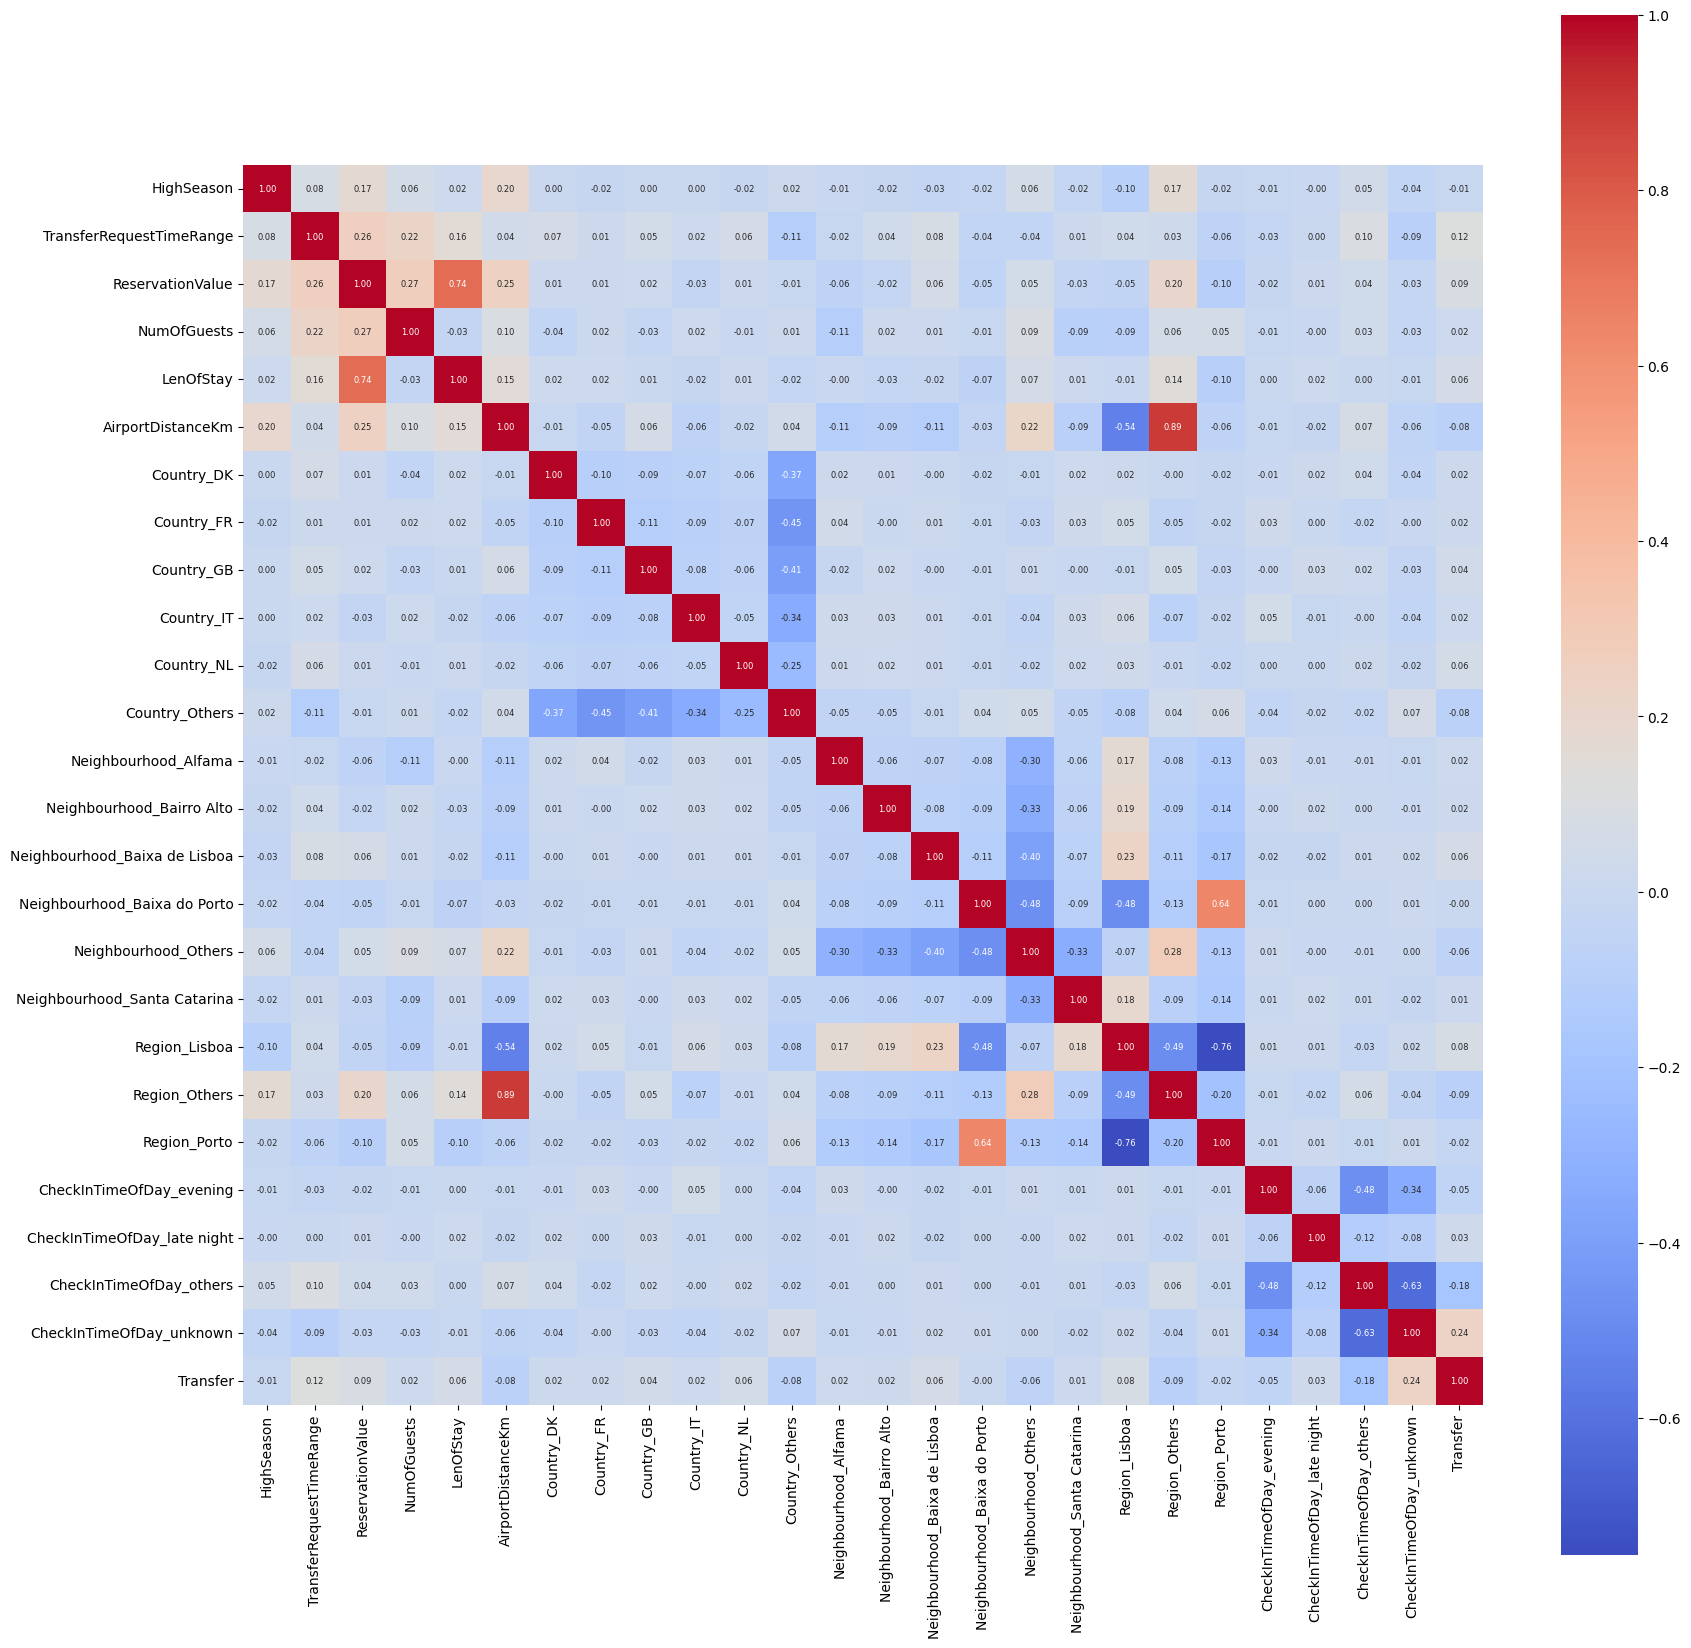

In [ ]:
# Get the correlation matrix
df_corr=df.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, annot_kws={"size": 6})
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

Interpretation of the Correlation Matrix:

Strongest Positive Correlations:

* **ReservationValue** and **NumOfGuests**: This relationship has a correlation of 0.83. It suggests that as the number of guests increases, the reservation value also tends to increase.

* **HighSeason** and **ReservationValue**: The correlation is 0.47, indicating that reservations tend to have higher values during the high season.

* **ReservationValue** and **LengthOfStay**: With a correlation of 0.43, this suggests that longer stays tend to have higher reservation values.

Strongest Negative Correlations:

* **Country_FR** and **AirportDistanceKm**: The correlation of -0.41 indicates an inverse relationship between the distance to the airport and a variable related to France.

* **CheckInTimeOfDay_others** and **LengthOfStay**: This correlation is -0.32, suggesting that check-ins at less common times may result in shorter stays.

* **Transfer** and **LengthOfStay**: The correlation is -0.24, indicating that bookings with transfers may be associated with shorter stays.

# 2. Training and Test Dataset Split

In [ ]:
# Split the dataframe into two: one for the predictors and one for the target
# Create one dataframe for the predictors and another for the target
X = df.drop('Transfer', axis=1)
y = df['Transfer']
y.value_counts()

,count
Transfer,
0,20950
1,1712


In [ ]:
# Configure and run k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_index, test_index in kf.split(X):
    # Split the data into training and test sets
     X_train, X_test = X.iloc[train_index], X.iloc[test_index]
     y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [ ]:
# The training dataset (predictors) corresponds to 80% of the total dataset (=18130/22662)
X_train

,HighSeason,TransferRequestTimeRange,ReservationValue,NumOfGuests,LenOfStay,AirportDistanceKm,Country_DK,Country_FR,Country_GB,Country_IT,...,Neighbourhood_Baixa do Porto,Neighbourhood_Others,Neighbourhood_Santa Catarina,Region_Lisboa,Region_Others,Region_Porto,CheckInTimeOfDay_evening,CheckInTimeOfDay_late night,CheckInTimeOfDay_others,CheckInTimeOfDay_unknown
0,0,355,343.440,3.0,4,7.6,0,0,1,0,...,0,1,0,1,0,0,0,0,1,0
1,0,227,726.336,4.0,3,7.6,0,0,0,0,...,0,1,0,1,0,0,1,0,0,0
2,0,216,1823.040,4.0,7,7.6,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
3,0,217,1044.120,4.0,4,7.6,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
4,0,106,1526.400,4.0,6,7.6,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22654,0,0,766.080,2.0,4,10.0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
22655,0,0,686.400,4.0,3,7.5,0,0,0,0,...,0,1,0,1,0,0,1,0,0,0
22656,0,0,454.800,3.0,2,8.6,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
22657,0,0,570.960,3.0,2,5.5,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1


In [ ]:
# Target (train)
y_train

,Transfer
0,0
1,1
2,0
3,1
4,0
...,...
22654,0
22655,0
22656,0
22657,0


In [ ]:
# The test dataset corresponds to 20% of the total dataset (=4532/22662)
X_test

,HighSeason,TransferRequestTimeRange,ReservationValue,NumOfGuests,LenOfStay,AirportDistanceKm,Country_DK,Country_FR,Country_GB,Country_IT,...,Neighbourhood_Baixa do Porto,Neighbourhood_Others,Neighbourhood_Santa Catarina,Region_Lisboa,Region_Others,Region_Porto,CheckInTimeOfDay_evening,CheckInTimeOfDay_late night,CheckInTimeOfDay_others,CheckInTimeOfDay_unknown
9,0,353,725.760,4.0,3,9.6,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
11,0,283,832.320,6.0,3,9.6,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
13,0,232,1530.000,6.0,4,9.6,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
16,0,360,285.120,4.0,3,16.7,0,0,0,0,...,1,0,0,0,0,1,1,0,0,0
24,0,126,400.128,5.0,3,13.1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22645,0,0,330.240,2.0,2,16.7,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
22652,0,1,857.280,2.0,3,110.0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
22658,0,0,1255.920,2.0,5,6.8,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
22659,0,0,475.200,3.0,2,10.0,0,1,0,0,...,0,1,0,1,0,0,0,0,1,0


# 3. Data Balancing

In [ ]:
# Use a data balancing strategy through oversampling
sampler = RandomOverSampler(sampling_strategy=1.0)  # 1.0 means that we want to ensure an equal proportion between the classes
X_train, y_train = sampler.fit_resample(X_train, y_train)  # We only want to apply balancing to the training set. The test set must remain as realistic as possible

y_train.value_counts()

,count
Transfer,
0,16793
1,16793


# 4. Predictive Modelling

## 4.1. Decision Tree

A decision tree is used to split data into classes or categories based on specific features. In this model, it is expected to predict the purchase of transfers based on decision rules extracted from the data’s characteristics.

In [ ]:
# Create a decision tree model
tree_classifier = tree.DecisionTreeClassifier()
# Train the decision tree
tree_classifier.fit(X_train, y_train)

DecisionTreeClassifier()

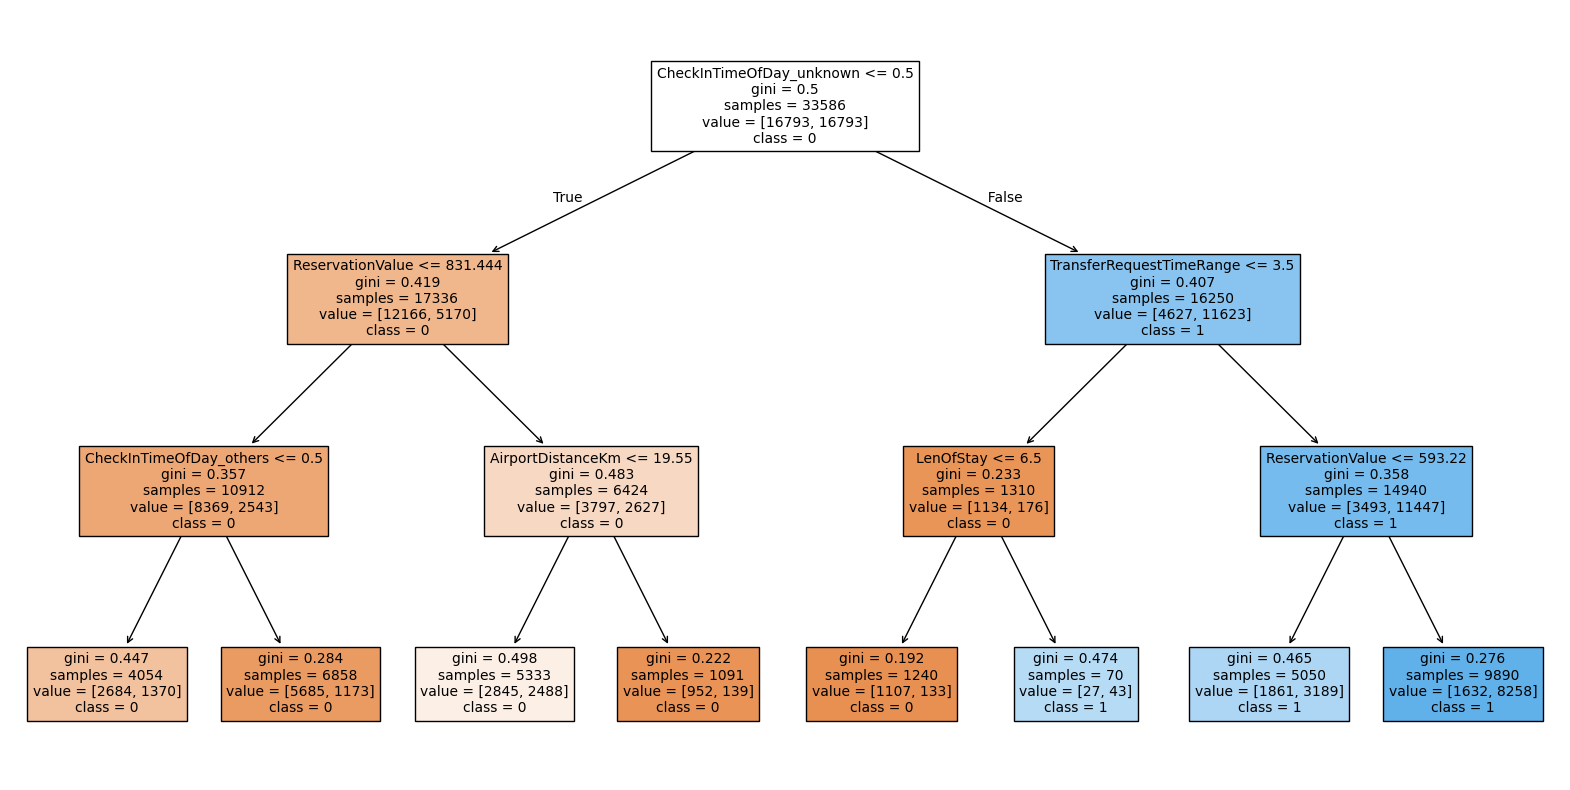

In [ ]:
# Create and train a decision tree with limited depth
tree_limited_depth = DecisionTreeClassifier(max_depth=3)  # for example, limiting the depth to 3
tree_limited_depth.fit(X_train, y_train)

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_limited_depth,
    filled=True,
    feature_names=X_train.columns,
    class_names=[str(cls) for cls in tree_limited_depth.classes_],
    fontsize=10
)
plt.show()

In [ ]:
# Classify the properties in the test sample
y_predicted = tree_classifier.predict(X_test)
y_predicted

array([1, 0, 0, ..., 0, 0, 0])

In [ ]:
# Auxiliary function to print metrics. It uses scoring functions already available in sklearn
def print_metrics(real, predictions):
  print("f1 score:", f1_score(real, predictions, average='macro'))
  print("accuracy score:", accuracy_score(real, predictions))
  print("AUC score:", roc_auc_score(real, predictions))

# Print metrics for the test dataset
print_metrics(y_test, y_predicted)

f1 score: 0.58237257592202
accuracy score: 0.8729037952338923
AUC score: 0.5825726886376392


* The F1_SCORE indicates the harmonic mean between precision and recall. An approximate value of 0.58 means that the model is reasonably good at predicting true positives, while also minimizing false negatives and false positives.
* The ACCURACY of approximately 0.88 is relatively high and indicates the proportion of correct predictions (both positive and negative) in relation to the total number of predictions made by the model.
* The Area Under the ROC Curve (AUC) value is an indicator of the model's ability to distinguish between classes. An AUC score of approximately 0.57 suggests that the model has a limited ability to distinguish between the positive and negative classes.

In [ ]:
# Print a short report with the results
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      4157
           1       0.23      0.23      0.23       375

    accuracy                           0.87      4532
   macro avg       0.58      0.58      0.58      4532
weighted avg       0.87      0.87      0.87      4532



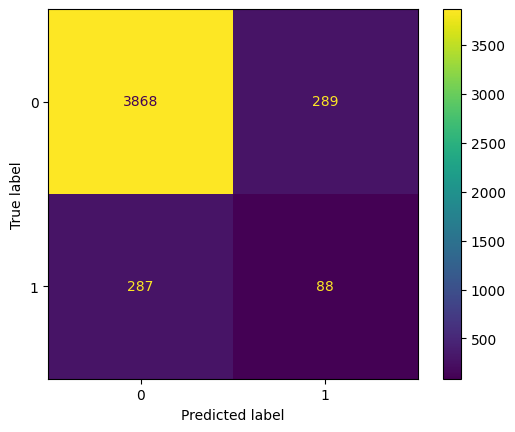

In [ ]:
# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_predicted)

The confusion matrix provides a detailed and quantitative view of the performance of our classification model. The model predicts:
* 3913 negative cases (TN)
* 302 cases as negative when they are actually positive (FN)
* 244 cases as positive when they are actually negative (FP)
* 73 positive cases (TP)

In [ ]:
# View feature importance according to the model
tree_classifier.feature_importances_

array([0.01602889, 0.23461481, 0.23794811, 0.06297771, 0.05333974,
       0.09609271, 0.00604848, 0.00923158, 0.01512852, 0.00640403,
       0.00470837, 0.02114311, 0.00380981, 0.00962178, 0.00589583,
       0.00529234, 0.00960771, 0.00797875, 0.00107413, 0.        ,
       0.00261991, 0.00168314, 0.00171065, 0.01328249, 0.1737574 ])

<Axes: xlabel='Importance', ylabel='Feature'>

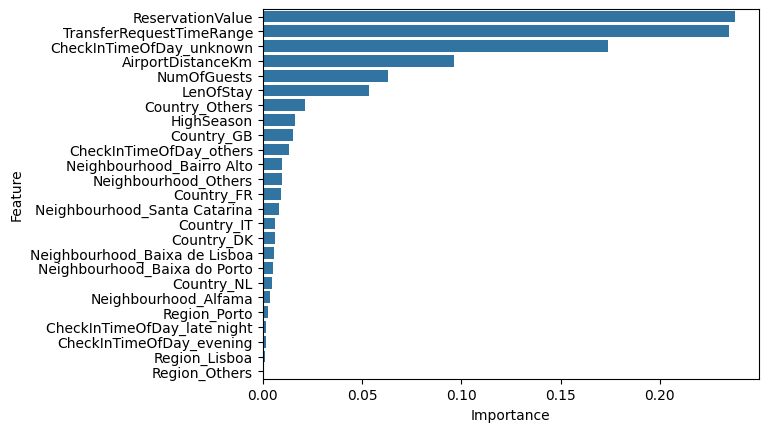

In [ ]:
# Create a dataframe with the feature importance values and their names
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': tree_classifier.feature_importances_})
# Sort the dataframe
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# Plot the chart
sns.barplot(data=feature_importance_df, y='Feature', x='Importance')

## 4.2. Results Optimization

In this section, we will explore other classification models, such as BaggingClassifier, GradientBoostingClassifier, XGBClassifier, and Random Forests.

### 4.2.1. Bagging Model

The Bagging model is used to create multiple models from random subsets of the original dataset. These models are trained independently, and their predictions are combined, typically through averaging, to produce a more stable and accurate final prediction, reducing variance and the risk of overfitting.

In [ ]:
# Initialize the base classifier
base_cls = DecisionTreeClassifier(random_state=42)

# Initialize the Bagging model with the base classifier
bagging_cls = BaggingClassifier(estimator=base_cls, n_estimators=10, random_state=42)

# Train the Bagging model
bagging_cls.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  random_state=42)

In [ ]:
# Make predictions on the test set
y_predicted = bagging_cls.predict(X_test)

In [ ]:
# Print metrics for the test dataset
print_metrics(y_test, y_predicted)

f1 score: 0.5987228145714825
accuracy score: 0.8989408649602825
AUC score: 0.5834220190842755


In [ ]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      4157
           1       0.32      0.21      0.25       375

    accuracy                           0.90      4532
   macro avg       0.63      0.58      0.60      4532
weighted avg       0.88      0.90      0.89      4532



### 4.2.2. Boosting Model

The Boosting algorithm trains models sequentially in order to correct errors and improve the accuracy of the final model. It is used to reduce bias and variance, resulting in more accurate and robust predictions.

#### 4.2.2.1. GradientBoostingClassifier

In [ ]:
# Create an instance of the GradientBoostingClassifier model
gradient_boosting = GradientBoostingClassifier(random_state=0)

# Train the model
gradient_boosting.fit(X_train, y_train)

GradientBoostingClassifier(random_state=0)

In [ ]:
# Classify the samples in the test dataset
y_predicted = gradient_boosting.predict(X_test)

# Print metrics for the test dataset
print_metrics(y_test, y_predicted)

f1 score: 0.6151789131266743
accuracy score: 0.7806707855251545
AUC score: 0.7688416325876032


In [ ]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.97      0.79      0.87      4157
           1       0.24      0.73      0.36       375

    accuracy                           0.79      4532
   macro avg       0.60      0.76      0.62      4532
weighted avg       0.91      0.79      0.83      4532



#### 4.2.2.2. XGBClassifier

The XGBClassifier is an implementation of the XGBoost algorithm for classification problems, based on the construction of multiple decision trees. It builds these trees sequentially, so that each new tree attempts to correct the errors made by the previous one.

In [ ]:
# Create an instance of the XGBoost classifier model
xgb = XGBClassifier()

# Train the model
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Classify the samples in the test dataset
y_predicted = xgb.predict(X_test)
# Print metrics for the test dataset
print_metrics(y_test, y_predicted)

f1 score: 0.6390274211654069
accuracy score: 0.8515004413062666
AUC score: 0.6958502124929836


* The F1 Score of 64.59% indicates that the model has a moderate performance in correctly identifying positive classes and being precise in its predictions.
* An Accuracy Score of 85.72% indicates that the model is correct in approximately 85.7% of its predictions, which is relatively high.
* An AUC ROC value of 70% suggests that the model has a reasonable ability to distinguish between positive and negative classes; however, there is still room for improvement. It should be noted that the closer this value is to 1, the greater the model’s discriminative ability (i.e., its capacity to distinguish between classes).

In [ ]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.95      0.88      0.92      4157
           1       0.28      0.51      0.36       375

    accuracy                           0.85      4532
   macro avg       0.62      0.70      0.64      4532
weighted avg       0.90      0.85      0.87      4532



<Axes: xlabel='Importance', ylabel='Feature'>

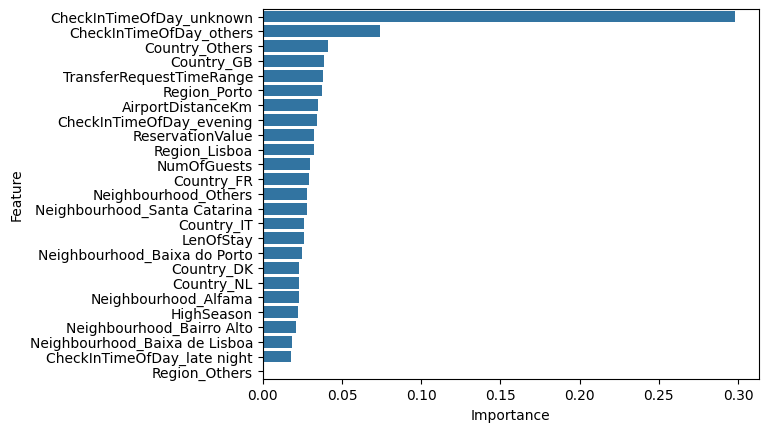

In [ ]:
# Create a dataframe with the feature importance values and their names
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb.feature_importances_})
# Sort the dataframe
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# Plot the chart
sns.barplot(data=feature_importance_df, y='Feature', x='Importance')

### 4.2.3. Random Forest

A Random Forest model is an algorithm that builds a collection of decision trees during training, producing predictions based on the aggregation of individual trees. Its purpose is to support automated and informed decision-making by classifying input data into predefined categories based on patterns learned during the training process.

In [ ]:
# Create and train the Random Forest model
rfc_model = RandomForestClassifier(random_state=0)

# Train the model
rfc_model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
# Make predictions and evaluate the model
y_predicted = rfc_model.predict(X_test)

# Print metrics for the test dataset
print_metrics(y_test, y_predicted)

f1 score: 0.6164670809697537
accuracy score: 0.9115180935569285
AUC score: 0.5914909790714457


In [ ]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      4157
           1       0.43      0.21      0.28       375

    accuracy                           0.91      4532
   macro avg       0.68      0.59      0.62      4532
weighted avg       0.89      0.91      0.90      4532



## 4.3. Grid Search

Modeling algorithms may have a large number of parameters, such as the depth of a tree. At the outset, it is not possible to know which parameter values will lead to the best model performance.

In order to improve the evaluation metrics of our classification models, particularly the F1-score, we will use the Grid Search technique to tune the hyperparameters of each model.

Grid Search is an exhaustive method that tests predefined combinations of hyperparameters. It is useful when the hyperparameter space is not too large, since the computational time increases rapidly with the number of combinations to be tested.

### 4.3.1. GridSearchCV - Decision Tree

In [ ]:
# Define the parameters and their respective ranges to be tested
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

In [ ]:
# Instantiate the Decision Tree model
dtree = DecisionTreeClassifier(random_state=42)

In [ ]:
# Configure GridSearchCV
grid_search = GridSearchCV(estimator=dtree, param_grid=param_grid, scoring='f1_macro', cv=3, verbose=1, n_jobs=-1)

In [ ]:
# Training GridSearchCV model
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 192 candidates, totalling 576 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 7, 10, 15],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1_macro', verbose=1)

In [ ]:
# Best parameters
print("Melhores parâmetros:", grid_search.best_params_)

Melhores parâmetros: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [ ]:
# Print metrics
print_metrics(y_test, y_predicted)

f1 score: 0.6164670809697537
accuracy score: 0.9115180935569285
AUC score: 0.5914909790714457


The metric values improve reasonably when Grid Search is applied to the Decision Tree model:

* The F1 score increases from 57.6% to 62.5%
* The accuracy score increases from 87.7% to 91.2%
* The AUC score increases from 57.3% to 59.9%

### 4.3.2. GridSearchCV - Bagging

In [ ]:
# Define the parameters and their respective ranges to be tested
param_grid = {
    'estimator__max_depth': [None, 3, 5, 7],
    'estimator__min_samples_leaf': [1, 2, 4],
    'max_samples': [0.5, 0.75, 1.0],
    'max_features': [0.5, 0.75, 1.0]
}

# Initialize the base classifier
base_cls = DecisionTreeClassifier(random_state=42)

# Initialize the Bagging classifier
bagging_cls = BaggingClassifier(estimator=base_cls, random_state=42)

# Configure GridSearchCV
grid_search = GridSearchCV(bagging_cls, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)

# Train the model with GridSearchCV
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                         random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [None, 3, 5, 7],
                         'estimator__min_samples_leaf': [1, 2, 4],
                         'max_features': [0.5, 0.75, 1.0],
                         'max_samples': [0.5, 0.75, 1.0]},
             scoring='f1_macro')

In [ ]:
# Get the best estimator
best_bagging_cls = grid_search.best_estimator_

In [ ]:
# Predict using the best estimator
y_predicted = best_bagging_cls.predict(X_test)

In [ ]:
# Better parameters
print("Melhores parâmetros:", grid_search.best_params_)

Melhores parâmetros: {'estimator__max_depth': None, 'estimator__min_samples_leaf': 1, 'max_features': 0.75, 'max_samples': 1.0}


In [ ]:
# Printing metrics
print_metrics(y_test, y_predicted)

f1 score: 0.5875031287687442
accuracy score: 0.911738746690203
AUC score: 0.5661371181140245


### 4.3.3. GridSearchCV - Gradient Boosting

In [ ]:
# Define the parameters and their respective ranges to be tested
param_grid = {
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2]
}

In [ ]:
# Instantiate the GradientBoostingClassifier model
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,  # You may reduce this number
    learning_rate=0.1,  # Start with a moderate learning rate
    random_state=0
)

In [ ]:
# Configurating GridSearchCV
grid_search = GridSearchCV(
    estimator=gradient_boosting,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,  # Reduced from 5 to 3
    n_jobs=-1,  # Use all available cores
    verbose=2
)

In [ ]:
# Training model with GridSearchCV
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=0),
             n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 4]},
             scoring='f1_macro', verbose=2)

In [ ]:
# Get the best estimator
best_model = grid_search.best_estimator_

In [ ]:
# Predict using the best estimator
y_predicted = best_model.predict(X_test)

In [ ]:
# Printing the metrics
print_metrics(y_test, y_predicted)

f1 score: 0.6362015223184607
accuracy score: 0.8150926743159753
AUC score: 0.7572788068318499


When Grid Search CV is applied to the Gradient Boosting model, adjusting the parameters within the defined ranges, the model’s performance improves slightly:

* f1_score increases from 61.17% to 63.69%
* accuracy score increases from 77.6% to 81.17%
* AUC score remains at 76%

### 4.3.4. GridSearchCV - XGBClassifier

In [ ]:
# Define the parameters and their respective ranges to be tested
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
}

In [ ]:
# Instantiate the model
xgb_gs = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Configure GridSearchCV
grid_search = GridSearchCV(estimator=xgb_gs, param_grid=param_grid, scoring='f1_macro', cv=3, verbose=1)

In [ ]:
# Training GridSearchCV
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 144 candidates, totalling 432 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:13:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:13:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:13:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:13:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2, 0.3],
                         'max_depth': [3, 4, 5, 6],
                         'subsample': [0.6, 0.8, 1.0]},
             scoring='f1_macro', verbose=1)

In [ ]:
# Best parameters
print("Best parameters:", grid_search.best_params_)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.3, 'max_depth': 6, 'subsample': 0.8}


In [ ]:
# Print Metrics
print_metrics(y_test, y_predicted)

f1 score: 0.6362015223184607
accuracy score: 0.8150926743159753
AUC score: 0.7572788068318499


### 4.3.5. GridSearchCV - Random Forest

In [ ]:
# Define the parameters and their respective ranges to be tested
param_grid_random_forest = {
    'max_features': ['sqrt', 'log2'],
    'max_depth' : [2,3,4],
    'criterion' :['gini', 'entropy']
}

# Define an instance of the classifier
classifier_random_forest = RandomForestClassifier()

# Define an instance of grid search
gs_random_forest = GridSearchCV(estimator=classifier_random_forest, param_grid=param_grid_random_forest, cv=5)

# Train the model with GridSearchCV
gs_random_forest.fit(X_train, y_train)

# View the parameters from the analysis that produced the best results
gs_random_forest.best_params_

{'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt'}

In [ ]:
# Classify the test sample
y_predicted = gs_random_forest.predict(X_test)

In [ ]:
# Print metrics - note that this method uses cross-validation, which generally implies a decrease in the metric values
print_metrics(y_test, y_predicted)

f1 score: 0.6012361634357094
accuracy score: 0.766548984995587
AUC score: 0.7550785021249299


# 5. Prediction of Transfers Purchased for New Bookings

## 5.1. Preparation and Processing of New Booking Data

In [ ]:
df_new_reservations = pd.read_excel("CPP_Transfer_Dataset.xlsx",sheet_name="NewReservations")
df_apartments = pd.read_excel("CPP_Transfer_Dataset.xlsx",sheet_name="Apartments")

In [ ]:
# Merge the New Bookings table with the Apartments table
df_final_predictions = pd.merge(df_new_reservations, df_apartments, on='ApartmentId')
df_final_predictions

,ReservationId,ApartmentId,CheckInDate,LenOfStay,OriginOTA,ReservationValue,ReservationDate,Country,CheckInTime,NumOfGuests,Region,Neighbourhood,ApartmentHasElevator,DoubeBeds,SingleBeds,SofaBeds,Typology,MaxOccupation
0,1812025125,409,2024-01-02,3,Booking,343.440,2023-06-08,BR,10:00:00,4.0,Lisboa,Marquês de Pombal,1,1.0,NaN,1.0,T1,4.0
1,1812035278,741,2024-01-02,3,Airbnb,410.400,2023-09-10,suecia,NaN,4.0,Lisboa,Almirante Reis,0,2.0,NaN,1.0,T2,4.0
2,1812032388,579,2024-01-10,2,Booking,285.120,2023-08-13,BR,NaN,6.0,Porto,Foz,0,NaN,4.0,1.0,T2,6.0
3,1879078187,161,2024-01-07,4,Booking,443.232,2023-11-23,AU,NaN,4.0,Lisboa,Alfama,0,1.0,NaN,1.0,T1,4.0
4,1879078518,788,2024-01-09,2,Airbnb,374.400,2023-11-27,NaN,NaN,6.0,Lisboa,Graça,1,2.0,2.0,NaN,T3,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388,1812036811,710,2024-01-08,4,Airbnb,489.600,2023-09-23,ES,NaN,6.0,Lisboa,Marquês de Pombal,0,2.0,2.0,NaN,T3,6.0
389,1812038185,985,2024-01-06,4,Booking,570.240,2023-10-07,BR,19:00:00,4.0,Lisboa,Bairro Alto,0,1.0,0.0,1.0,T1,4.0
390,1879080298,736,2024-01-03,2,Airbnb,302.400,2023-12-24,NaN,15:00:00,1.0,Lisboa,Intendente,0,1.0,2.0,1.0,T2,6.0
391,1879080676,653,2024-01-01,3,Booking,410.400,2023-12-29,ES,NaN,4.0,Porto,Porto,0,1.0,2.0,NaN,T2,4.0


In [ ]:
# Validate that the new dataset was created successfully
output_filepath = '/content/CPS_Dataset_Final_New_Reservations.xlsx'
df_final_predictions.to_excel(output_filepath, index=False)
output_filepath

'/content/CPS_Dataset_Final_New_Reservations.xlsx'

In [ ]:
# Function to identify High Season based on 'CheckInDate'
def high_season(checkin_date):
    return 1 if checkin_date.month in [6, 7, 8, 9] else 0

# Apply the function to the dataframe to create the 'HighSeason' column
df_final_predictions['HighSeason'] = df_final_predictions['CheckInDate'].apply(high_season)

In [ ]:
# Convert the date columns to datetime type
df_final_predictions['ReservationDate'] = pd.to_datetime(df_final_predictions['ReservationDate'])
df_final_predictions['CheckInDate'] = pd.to_datetime(df_final_predictions['CheckInDate'])

# Calculate the 'TransferRequestTimeRange' column, given by the difference in days between CheckInDate and ReservationDate
df_final_predictions['TransferRequestTimeRange'] = (
    df_final_predictions['CheckInDate'] - df_final_predictions['ReservationDate']
).dt.days

In [ ]:
# Function to classify CheckInTime
def classify_time_of_day(time):
    if pd.isnull(time):
        return 'unknown'
    else:
        hour = time.hour
        if 6 <= hour < 12:
            return 'morning'
        elif 12 <= hour < 18:
            return 'afternoon'
        elif 18 <= hour < 24:
            return 'evening'
        else:
            return 'late night'

# Create the new 'CheckInTimeOfDay' column
df_final_predictions['CheckInTime'] = pd.to_datetime(
    df_final_predictions['CheckInTime'],
    format='%H:%M:%S',
    errors='coerce'
)
df_final_predictions['CheckInTimeOfDay'] = df_final_predictions['CheckInTime'].apply(classify_time_of_day)

In [ ]:
# Select the top 3 CheckInTimeOfDay categories with the highest percentage of purchased transfers (as shown earlier)
top_checkintimeofday = ['unknown', 'late night', 'evening']

df_final_predictions['CheckInTimeOfDay'] = df_final_predictions['CheckInTimeOfDay'].apply(
    lambda x: x if x in top_checkintimeofday else 'others'
)

unique_checkintimeofday = df_final_predictions['CheckInTimeOfDay'].unique()
print("Unique values in 'CheckInTimeOfDay':", unique_checkintimeofday)

Unique values in 'CheckInTimeOfDay': ['others' 'unknown' 'evening' 'late night']


In [ ]:
df_final_predictions["Country"] = df_final_predictions["Country"].astype(str)

# Change "frança" to "FR" (it is the only country in the top 5 with a non-standardized value)
df_final_predictions["Country"] = df_final_predictions["Country"].apply(
    lambda x: "FR" if x.lower() == "frança" else x
)

# We will only keep the top 5 countries with the highest percentage of purchased transfers (as identified earlier)
top_countries = ['NL', 'GB', 'IT', 'DK', 'FR']

# Replace all remaining countries with 'Others'
df_final_predictions['Country'] = df_final_predictions['Country'].apply(
    lambda x: x if x in top_countries else 'Others'
)

# List distinct values for 'Country'
unique_countries = df_final_predictions['Country'].unique()
print("Unique values in 'Country':", unique_countries)

Unique values in 'Country': ['Others' 'GB' 'IT' 'FR' 'NL']


In [ ]:
# Rename the value 'Foz' in the 'Neighbourhood' column to 'Foz do Douro' to keep it consistent with the initial dataset (checkpoint)
df_final_predictions.loc[df_final_predictions['Neighbourhood'] == 'Foz', 'Neighbourhood'] = 'Foz do Douro'

In [ ]:
# Update 'Neighbourhood' to 'Baixa de Lisboa' where 'Region' is 'Lisboa' and 'Neighbourhood' is 'Baixa'
df_final_predictions.loc[
    (df_final_predictions['Region'] == 'Lisboa') & (df_final_predictions['Neighbourhood'] == 'Baixa'),
    'Neighbourhood'
] = 'Baixa de Lisboa'

# Update 'Neighbourhood' to 'Baixa do Porto' where 'Region' is 'Porto' and 'Neighbourhood' is 'Baixa'
df_final_predictions.loc[
    (df_final_predictions['Region'] == 'Porto') & (df_final_predictions['Neighbourhood'] == 'Baixa'),
    'Neighbourhood'
] = 'Baixa do Porto'

In [ ]:
# Replace blank values in the 'Neighbourhood' column with the corresponding mode values of 'Region'
neighbourhood_mode_mapping = {
    'Algarve': 'Carrapateira',
    'Ericeira': 'Ericeira',
    'Porto': 'Baixa do Porto',
    'Lisboa': 'Baixa de Lisboa'
}

for region, mode_value in neighbourhood_mode_mapping.items():
    df_final_predictions.loc[
        (df_final_predictions['Region'] == region) & (df_final_predictions['Neighbourhood'].isnull()),
        'Neighbourhood'
    ] = mode_value

unique_bairros = df_final_predictions['Neighbourhood'].unique()
print("Unique values in 'Neighbourhood':", unique_bairros)

Unique values in 'Neighbourhood': ['Marquês de Pombal' 'Almirante Reis' 'Foz do Douro' 'Alfama' 'Graça'
 'Principe Real' 'Chiado' 'Baixa de Lisboa' 'Cais do Sodré'
 'Baixa do Porto' 'Martim Moniz' 'Restauradores' 'Bairro Alto' 'Sé'
 'Av. da Liberdade' 'Ericeira' 'S. Bento' 'Intendente' 'Trindade'
 'Boavista' 'Porto' 'Santa Catarina' 'Campo de Ourique' 'Benfica' 'Lapa'
 'Santa Marta' 'Carrapateira' 'Madragoa' 'Cedofeita' 'S. José' 'Av. Novas'
 'Beato' 'Saldanha' 'Rato']


In [ ]:
# Create a dictionary with the neighbourhoods and their respective distances to the airport
distances = {
    'Alfama': 6.8,
    'Almirante Reis': 5.1,
    'Av. da Liberdade': 7.6,
    'Av. Novas': 5.6,
    'Bairro Alto': 9.9,
    'Baixa de Lisboa': 9.6,
    'Baixa do Porto': 16.7,
    'Beato': 6.3,
    'Benfica': 8.8,
    'Bica': 9.1,
    'Boavista': 14.3,
    'Cais do Sodré': 9.7,
    'Campo de Ourique': 10.9,
    'Carrapateira': 110.0,
    'Castelo': 8.1,
    'Cedofeita': 15.5,
    'Chiado': 10.1,
    'Ericeira': 46.0,
    'Estrela': 12.5,
    'Foz do Douro': 14.8,
    'Graça': 7.5,
    'Intendente': 5.5,
    'Lapa': 13.1,
    'Madragoa': 10.0,
    'Marquês de Pombal': 6.9,
    'Martim Moniz': 6.3,
    'Mercês': 23.7,
    'Mouraria': 6.7,
    'Olivais': 1.0,
    'Porto': 13.1,
    'Principe Real': 8.6,
    'Rato': 8.1,
    'Restauradores': 7.2,
    'Restelo': 14.4,
    'Ribeira': 22.3,
    'S. Bento': 8.5,
    'S. José': 6.5,
    'Saldanha': 5.8,
    'Santa Catarina': 10.0,
    'Santa Marta': 8.4,
    'Sé': 10.0,
    'Trindade': 16.8
}

# Apply the mapping to the DataFrame to create the new column
df_final_predictions['AirportDistanceKm'] = df_final_predictions['Neighbourhood'].map(distances)

In [ ]:
# Save the modified dataframe to a new Excel file
modified_file_path = '/content/CPS_Dataset_Final_Predictions_Modified.xlsx'
df_final_predictions.to_excel(modified_file_path, index=False)

modified_file_path

'/content/CPS_Dataset_Final_Predictions_Modified.xlsx'

In [ ]:
# Select the top 5 neighbourhoods with the highest percentage of purchased transfers (as identified earlier)
top_neighbourhoods = ['Baixa do Porto', 'Baixa de Lisboa', 'Bairro Alto', 'Santa Catarina', 'Alfama']

df_final_predictions['Neighbourhood'] = df_final_predictions['Neighbourhood'].apply(
    lambda x: x if x in top_neighbourhoods else 'Others'
)

unique_neighbourhoods = df_final_predictions['Neighbourhood'].unique()
print("Unique values in 'Neighbourhood':", unique_neighbourhoods)

Unique values in 'Neighbourhood': ['Others' 'Alfama' 'Baixa de Lisboa' 'Baixa do Porto' 'Bairro Alto'
 'Santa Catarina']


In [ ]:
# Select the 2 regions with the highest percentage of purchased transfers (as identified earlier)
top_regions = ['Lisboa', 'Porto']

df_final_predictions['Region'] = df_final_predictions['Region'].apply(
    lambda x: x if x in top_regions else 'Others'
)

unique_regions = df_final_predictions['Region'].unique()
print("Unique values in 'Region':", unique_regions)

Unique values in 'Region': ['Lisboa' 'Porto' 'Others']


In [ ]:
# ReservationValue e NumOfGuests -> substituir valores a NULL pela média da coluna
mean_reservation_value = round(df_final_predictions['ReservationValue'].mean(), 3)
mean_num_of_guests = round(df_final_predictions['NumOfGuests'].mean())
df_final_predictions['ReservationValue'].fillna(mean_reservation_value, inplace=True)
df_final_predictions['NumOfGuests'].fillna(mean_num_of_guests, inplace=True)

/tmp/ipykernel_3060/371463336.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final_predictions['ReservationValue'].fillna(mean_reservation_value, inplace=True)
/tmp/ipykernel_3060/371463336.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [ ]:
# Apply get_dummies to the columns Country, Neighbourhood, Region, and CheckInTimeOfDay
dummies = pd.get_dummies(df_final_predictions[['Country', 'Neighbourhood', 'Region', 'CheckInTimeOfDay']], dtype=int)
df_with_dummies = pd.concat([df_final_predictions, dummies], axis=1)

# Remove the original text columns from which the dummy variables were created
columns_to_drop = ['Country', 'Neighbourhood', 'Region', 'CheckInTimeOfDay']
df_final_predictions = df_with_dummies.drop(columns=columns_to_drop)

In [ ]:
# We need to manually add the 'Country_DK' column to the dataset, since there are no records in NewReservations with Country='DK', but this is one of the variables considered in the training of our model
df_final_predictions['Country_DK'] = 0

colunas = list(df_final_predictions.columns)
index_nl = colunas.index('Country_NL')
colunas.remove('Country_DK')
colunas.insert(index_nl + 1, 'Country_DK')

df_final_predictions = df_final_predictions[colunas]

In [ ]:
columnstodrop=['ApartmentId', 'CheckInDate','CheckInTime', 'ReservationDate','OriginOTA', 'ApartmentHasElevator', 'DoubeBeds', 'SingleBeds', 'SofaBeds', 'Typology', 'MaxOccupation']
df_final_predictions = df_final_predictions.drop(columns=columnstodrop)

In [ ]:
df_final_predictions

,ReservationId,LenOfStay,ReservationValue,NumOfGuests,HighSeason,TransferRequestTimeRange,AirportDistanceKm,Country_FR,Country_GB,Country_IT,...,Neighbourhood_Baixa do Porto,Neighbourhood_Others,Neighbourhood_Santa Catarina,Region_Lisboa,Region_Others,Region_Porto,CheckInTimeOfDay_evening,CheckInTimeOfDay_late night,CheckInTimeOfDay_others,CheckInTimeOfDay_unknown
0,1812025125,3,343.440,4.0,0,208,6.9,0,0,0,...,0,1,0,1,0,0,0,0,1,0
1,1812035278,3,410.400,4.0,0,114,5.1,0,0,0,...,0,1,0,1,0,0,0,0,0,1
2,1812032388,2,285.120,6.0,0,150,14.8,0,0,0,...,0,1,0,0,0,1,0,0,0,1
3,1879078187,4,443.232,4.0,0,45,6.8,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,1879078518,2,374.400,6.0,0,43,7.5,0,0,0,...,0,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388,1812036811,4,489.600,6.0,0,107,6.9,0,0,0,...,0,1,0,1,0,0,0,0,0,1
389,1812038185,4,570.240,4.0,0,91,9.9,0,0,0,...,0,0,0,1,0,0,1,0,0,0
390,1879080298,2,302.400,1.0,0,10,5.5,0,0,0,...,0,1,0,1,0,0,0,0,1,0
391,1879080676,3,410.400,4.0,0,3,13.1,0,0,0,...,0,1,0,0,0,1,0,0,0,1


In [ ]:
df.columns

Index(['HighSeason', 'TransferRequestTimeRange', 'ReservationValue',
       'NumOfGuests', 'LenOfStay', 'AirportDistanceKm', 'Country_DK',
       'Country_FR', 'Country_GB', 'Country_IT', 'Country_NL',
       'Country_Others', 'Neighbourhood_Alfama', 'Neighbourhood_Bairro Alto',
       'Neighbourhood_Baixa de Lisboa', 'Neighbourhood_Baixa do Porto',
       'Neighbourhood_Others', 'Neighbourhood_Santa Catarina', 'Region_Lisboa',
       'Region_Others', 'Region_Porto', 'CheckInTimeOfDay_evening',
       'CheckInTimeOfDay_late night', 'CheckInTimeOfDay_others',
       'CheckInTimeOfDay_unknown', 'Transfer'],
      dtype='object')

In [ ]:
df_final_predictions.columns

Index(['ReservationId', 'LenOfStay', 'ReservationValue', 'NumOfGuests',
       'HighSeason', 'TransferRequestTimeRange', 'AirportDistanceKm',
       'Country_FR', 'Country_GB', 'Country_IT', 'Country_NL', 'Country_DK',
       'Country_Others', 'Neighbourhood_Alfama', 'Neighbourhood_Bairro Alto',
       'Neighbourhood_Baixa de Lisboa', 'Neighbourhood_Baixa do Porto',
       'Neighbourhood_Others', 'Neighbourhood_Santa Catarina', 'Region_Lisboa',
       'Region_Others', 'Region_Porto', 'CheckInTimeOfDay_evening',
       'CheckInTimeOfDay_late night', 'CheckInTimeOfDay_others',
       'CheckInTimeOfDay_unknown'],
      dtype='object')

In [ ]:
# Store the 'ReservationId' column
reservation_ids = df_final_predictions['ReservationId']

# Ensure that df_final_predictions has the same columns as df (except for the target column 'Transfer') and reorder the columns so that they match the order of df
column_order = [col for col in df.columns if col != 'Transfer']
df_final_predictions = df_final_predictions[column_order]

In [ ]:
df_final_predictions.columns

Index(['HighSeason', 'TransferRequestTimeRange', 'ReservationValue',
       'NumOfGuests', 'LenOfStay', 'AirportDistanceKm', 'Country_DK',
       'Country_FR', 'Country_GB', 'Country_IT', 'Country_NL',
       'Country_Others', 'Neighbourhood_Alfama', 'Neighbourhood_Bairro Alto',
       'Neighbourhood_Baixa de Lisboa', 'Neighbourhood_Baixa do Porto',
       'Neighbourhood_Others', 'Neighbourhood_Santa Catarina', 'Region_Lisboa',
       'Region_Others', 'Region_Porto', 'CheckInTimeOfDay_evening',
       'CheckInTimeOfDay_late night', 'CheckInTimeOfDay_others',
       'CheckInTimeOfDay_unknown'],
      dtype='object')

In [ ]:
modified_file_path = '/content/CPS_Dataset_Final_Predictions_Modified.xlsx'
df_final_predictions.to_excel(modified_file_path, index=False)
modified_file_path

'/content/CPS_Dataset_Final_Predictions_Modified.xlsx'

We chose the XGBClassifier model, defined in Section 4.2.2.2, to perform our predictions because it is the model for which we obtained the highest f1_score value, approximately 64.59%.

In [ ]:
# Apply the trained model to the new bookings dataset to generate predictions
predictions = xgb.predict(df_final_predictions)

# Create a DataFrame for the predictions with the 'ReservationId' column
predictions_df = pd.DataFrame({
    'ReservationId': reservation_ids,
    'Predicted_Transfer': predictions
})

# Save the predictions DataFrame to a new Excel file
output_path = '/content/predictions.xlsx'
predictions_df.to_excel(output_path, index=False)